In [1]:
import numpy as np 
import pandas as pd
from src import utils, db, behavmatch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
def dprime_cell(response, condition1, condition2, discrimination_region=(0,100), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

def compute_cell_change(name, date, blk, tshs=[(0.3,0.5), (0.5,1), (1,10)]):
    areas = ["V1", "medial", "lateral", "anterior"]
    obj_path = Path(r"D:\mouseobj")
    m1 = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
    ctypes = 2
    proportion = np.empty((len(areas), len(tshs), ctypes, 2, 2))
    save_pth = obj_path.joinpath(name,date,blk)
    trial_no = utils.get_trialno_bytype(m1.frameselector)
    if not save_pth.exists():
        save_pth.mkdir(parents=True)
    for isel, _ in enumerate(["prototype", "non prototype"]):
        print(f"selection: {isel}")
        if isel == 0:
            dprime = dprime_cell(m1.interp_spks, trial_no["rewarded"], trial_no["non rewarded"], discrimination_region=(0,100))
        elif isel == 1:
            dprime = dprime_cell(m1.interp_spks, trial_no["rewarded test"], trial_no["non rewarded test"], discrimination_region=(0,100))
        else:
            raise ValueError("Selection type not recognized")
        for indexa, area in enumerate(areas):
            print(f"area: {area}")
            ia = utils.get_region_idx(m1.iarea, area)
            for redcell in range(ctypes):
                print(f"cell type: {redcell}")
                if redcell == 0:
                    selected_type = np.logical_not(m1.isred[:, 0]).astype(bool)
                else:
                    selected_type = m1.isred[:, 0].astype(bool)
                # proportion of cells changing
                for it, tsh in enumerate(tshs):
                    print(f"threshold: {tsh}")
                    prefer_r_1 = (dprime >= tsh[0]) * (dprime < tsh[1])
                    prefer_nr_1 = (dprime > -tsh[1]) * (dprime <= -tsh[0])
                    area_prefer_r_1 = prefer_r_1 * ia * selected_type
                    area_prefer_nr_1 = prefer_nr_1 * ia * selected_type
                    proportion[indexa, it, redcell, isel, 0] = (area_prefer_r_1.sum()) / (ia * selected_type).sum()
                    proportion[indexa, it, redcell, isel, 1] = (area_prefer_nr_1.sum()) / (ia * selected_type).sum()
    np.save(save_pth / "proportion_cells_0_100_tshs.npy", proportion)

def compute_cell_change_matched(name, date, blk, tshs=[(0.3,0.5), (0.5,1), (1,10)], matched=False):
    areas = ["V1", "medial", "lateral", "anterior"]
    obj_path = Path(r"D:\mouseobj")
    m1 = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
    ctypes = 2
    proportion = np.empty((len(areas), len(tshs), ctypes, 2, 2))
    save_pth = obj_path.joinpath(name,date,blk)
    trial_no = utils.get_trialno_bytype(m1.frameselector)
    if matched:
        m_rew, m_nrew, m_rew_test, m_nrew_test = behavmatch.get_matched_trials(m1, save_pth)
    else:
        m_rew, m_nrew, m_rew_test, m_nrew_test = trial_no["rewarded"], trial_no["non rewarded"], trial_no["rewarded test"], trial_no["non rewarded test"]
    if not save_pth.exists():
        save_pth.mkdir(parents=True)
    for isel, _ in enumerate(["prototype", "non prototype"]):
        print(f"selection: {isel}")
        if isel == 0:
            dprime = dprime_cell(m1.interp_spks, m_rew, m_nrew, discrimination_region=(0,100))
        elif isel == 1:
            dprime = dprime_cell(m1.interp_spks, m_rew_test, m_nrew_test, discrimination_region=(0,100))
        else:
            raise ValueError("Selection type not recognized")
        for indexa, area in enumerate(areas):
            print(f"area: {area}")
            ia = utils.get_region_idx(m1.iarea, area)
            for redcell in range(ctypes):
                print(f"cell type: {redcell}")
                if redcell == 0:
                    selected_type = np.logical_not(m1.isred[:, 0]).astype(bool)
                else:
                    selected_type = m1.isred[:, 0].astype(bool)
                # proportion of cells changing
                for it, tsh in enumerate(tshs):
                    print(f"threshold: {tsh}")
                    prefer_r_1 = (dprime >= tsh[0]) * (dprime < tsh[1])
                    prefer_nr_1 = (dprime > -tsh[1]) * (dprime <= -tsh[0])
                    area_prefer_r_1 = prefer_r_1 * ia * selected_type
                    area_prefer_nr_1 = prefer_nr_1 * ia * selected_type
                    proportion[indexa, it, redcell, isel, 0] = (area_prefer_r_1.sum()) / (ia * selected_type).sum()
                    proportion[indexa, it, redcell, isel, 1] = (area_prefer_nr_1.sum()) / (ia * selected_type).sum()
    np.save(save_pth / "proportion_cells_0_100_tshs.npy", proportion)




In [3]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
working_dbase

,mname,datexp,blk,session,round_id,recording,obj,name_round
0,VG11,2024_10_15,4,all rewarded before,1,True,old,VG11_1
1,VG11,2024_10_16,2,first training,1,True,old,VG11_1
2,VG11,2024_10_31,2,last training,1,True,old,VG11_1
3,VG11,2024_11_01,2,all rewarded after,1,True,old,VG11_1
4,VG11,2024_11_04,2,all rewarded before,2,True,old,VG11_2
5,VG11,2024_11_05,3,first training,2,True,old,VG11_2
6,VG11,2024_11_14,2,last training,2,True,old,VG11_2
7,VG11,2024_11_15,2,all rewarded after,2,True,old,VG11_2
8,VG14,2024_10_15,2,all rewarded before,1,True,old,VG14_1
9,VG14,2024_10_16,2,first training,1,True,old,VG14_1


In [66]:
m = utils.load_mouse('VGa9', '2025_11_06', '4', load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_06\4
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [73]:
m2 = utils.load_mouse('VGa9', '2025_11_20', '2', load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_20\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [82]:
save_pth = Path(r"D:\mouseobj\VGa9\2025_11_06\4")
dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))

In [140]:
def get_matched_trials(m):
    object_path = Path(r"D:\mouseobj")
    cbin = 3 
    name, datexp, blk = m.name, m.datexp, m.blk
    save_pth = object_path.joinpath(name,datexp,blk)
    protA = m.trial_dict["rewarded"]
    protB = m.trial_dict["non rewarded"]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
    m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
    m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
    m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
    trial_dict_matched = {"rewarded": m_rew,
                        "non rewarded": m_nrew,
                        "rewarded test": m_rew_test,
                        "non rewarded test": m_nrew_test}
    return trial_dict_matched

from scipy import ndimage
def get_density_map(m, session: str, celltype: str = 'Pyr', sig = 30, sig_bg = 30, xoff = 800, yoff = 800, tsh = .5, downsample=10):
    ixy, arid = m.xy_t, m.iarea
    if session == "last training (matched)":
        trial_dict = get_matched_trials(m)
    else:
        trial_dict = m.trial_dict
    dp = dprime_cell(m.interp_spks, trial_dict["rewarded test"], trial_dict["non rewarded test"], discrimination_region=(0,100), subpop=None)
    idx = abs(dp) >= tsh 
    sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if celltype == 'Pyr' else m.isred[:, 0].astype(bool)      
    idx_neu = (arid!=-1) & (arid != 7) & sel_type  # exclude neurons from outside of visual cortex & red cells if specified
    nneu = idx_neu.sum() # total neurons
    xpos, ypos = -ixy[idx_neu, 1], ixy[idx_neu, 0]
    x, y = xpos+xoff, ypos+yoff
    sel_idx = idx[idx_neu]
    bg, img = np.zeros((5000,5000)), np.zeros((5000,5000))
    bg[y.astype(int), x.astype(int)] = 1.0
    bg = ndimage.gaussian_filter(bg, sigma=1, truncate=sig_bg)>0 # create a background map
    bg = bg.astype(float)
    bg[bg == False] = np.nan # fill empty space with nan
    img[y[sel_idx].astype(int), x[sel_idx].astype(int)] = 1
    img = ndimage.gaussian_filter(img, sigma=sig)
    img[np.isnan(bg)] = np.nan
    img = np.fliplr(img)
    img = img/nneu
    img = img[::downsample,::downsample]
    return img

def plot_density_map(ax, m, pmap: np.array, vmax: int, cmap: str = "magma", scal: int = 10):
    sz = pmap.shape[0]
    scal = 10
    ax.imshow(np.flipud(pmap), cmap=cmap, vmax=vmax, extent=[0, sz*scal, 0, sz*scal], rasterized=True)
    outlines = m.outline
    temp_outline=[]
    for j in range(10):
        if j!=7:
            temp = outlines[j].copy()
            temp[:,1] = -(-temp[:,1]+700-2500)+2500
            temp[:,0] = temp[:,0]+700
            ax.plot(temp[:,1],temp[:,0], linewidth=0.7, color='k')  
            temp_outline.append(temp)
        else:
            temp_outline.append([])

In [ ]:
xoff, yoff = 800, 800   
ixy, arid = m.xy_t, m.iarea
dp = dp_nonprot
idx = abs(dp) >= .5         
idx_neu = (arid!=-1) & (arid != 7) # exclude neurons from outside of visual cortex
nneu = idx_neu.sum() # total neurons
xpos, ypos = -ixy[idx_neu, 1], ixy[idx_neu, 0]

In [84]:
from scipy import ndimage
sig=30 
sig_bg=30
xoff, yoff = 800, 800
x, y = xpos+xoff, ypos+yoff
sel_idx = idx[idx_neu]
bg, img = np.zeros((5000,5000)), np.zeros((5000,5000))
bg[y.astype(int), x.astype(int)] = 1.0
bg = ndimage.gaussian_filter(bg, sigma=1, truncate=sig_bg)>0 # create a background map
bg = bg.astype(float)
bg[bg==False] = np.nan # fill empty space with nan
if any(sel_idx != None):
    img[y[sel_idx].astype(int), x[sel_idx].astype(int)] = 1
img = ndimage.gaussian_filter(img, sigma=sig)
img[np.isnan(bg)] = np.nan
img = np.fliplr(img)

In [85]:
img = img/nneu # devided by total neurons
#img = np.nanmean(np.array(img), axis=0) # mean across mice
ndown = 10
imgs = {'img':img[::ndown, ::ndown], 'n_down':ndown} # scale d

In [92]:
m

Mouse(name='VGa9', datexp='2025_11_06', blk='4', data_path='Z:/data/PROC')

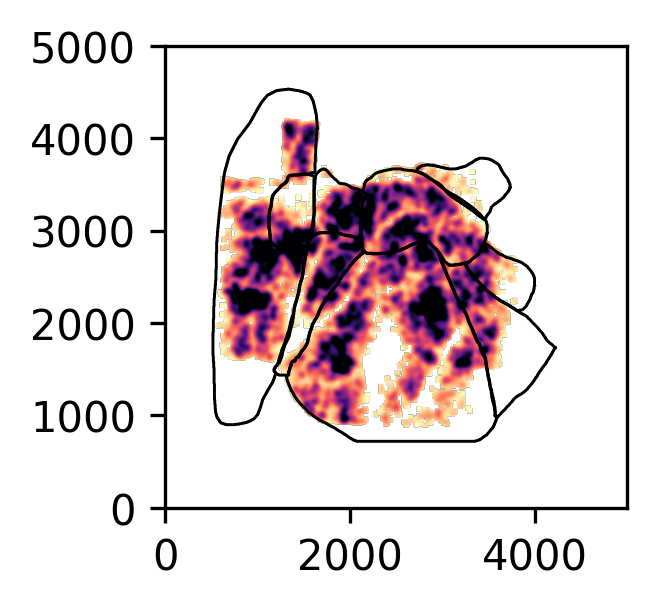

In [253]:
img = get_density_map(m2, 'last training', celltype='Pyr', sig = 30, sig_bg = 30, xoff = 700, yoff = 700, tsh = .5, downsample=10)
vmax = np.quantile(img[np.where(~np.isnan(img))], .90)
fig, ax = plt.subplots(1, 1, figsize=(2,2), dpi=300)
plot_density_map(ax, m2, img, vmax = vmax, cmap = "magma_r")

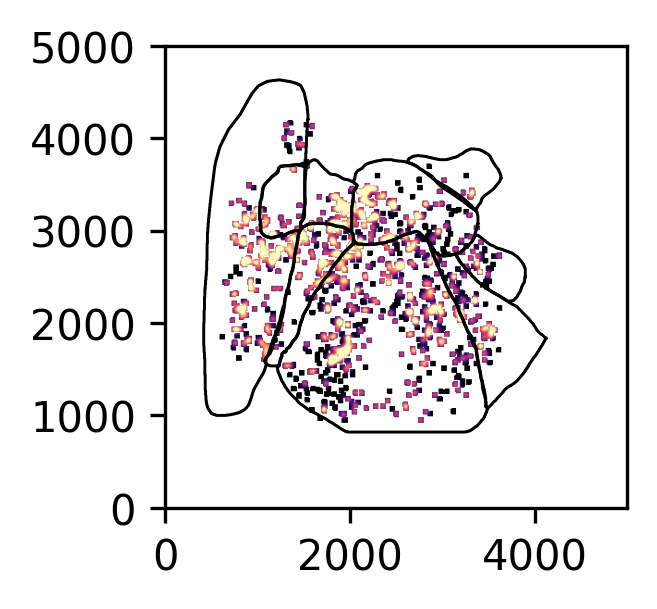

In [113]:
img = get_density_map(m2, 'last training', celltype='Int', sig = 30, sig_bg = 30, xoff = 700, yoff = 700, tsh = .5, downsample=10)
vmax = np.quantile(img[np.where(~np.isnan(img))], .90)
fig, ax = plt.subplots(1, 1, figsize=(2,2), dpi=300)
plot_density_map(ax, m2, img, vmax = vmax)

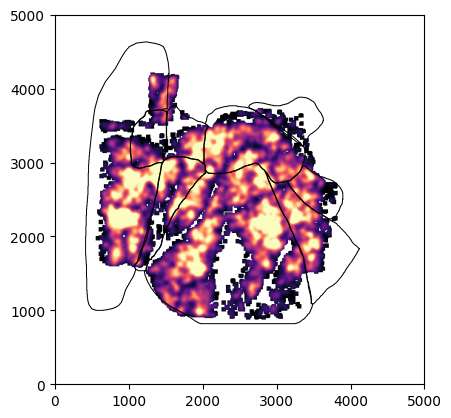

In [100]:
sz = img.shape[0]
scal = 10
plt.imshow(np.flipud(img), cmap='magma', vmax=vmax, extent=[0, sz*scal, 0, sz*scal], rasterized=True)
outlines = m.outline
temp_outline=[]
for j in range(10):
    if j!=7:
        temp = outlines[j].copy()
        temp[:,1] = -(-temp[:,1]+800-2500)+2500
        temp[:,0] = temp[:,0]+800
        plt.plot(temp[:,1],temp[:,0], linewidth=0.7, color='k')  
        temp_outline.append(temp)
    else:
        temp_outline.append([])

In [78]:
vmax = np.quantile(imgs['img'][np.where(~np.isnan(imgs['img']))], 0.90)

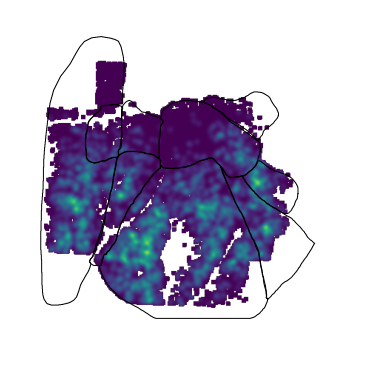

In [86]:
sz = imgs['img'].shape[0]
scal = 10
plt.imshow(np.flipud(imgs['img']), cmap='viridis', vmax=vmax, extent=[0, sz*scal, 0, sz*scal], rasterized=True)
outlines = m.outline
temp_outline=[]
for j in range(10):
    if j!=7:
        temp = outlines[j].copy()
        temp[:,1] = -(-temp[:,1]+800-2500)+2500
        temp[:,0] = temp[:,0]+800
        plt.plot(temp[:,1],temp[:,0], linewidth=0.7, color='k')  
        temp_outline.append(temp)
    else:
        temp_outline.append([])
plt.axis('off');

In [4]:
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)
print(f"Number of mice: {nmice}, number of sessions: {n_sessions}, number of areas: {nareas}, number of cell types: {ncelltypes}")

Number of mice: 10, number of sessions: 4, number of areas: 4, number of cell types: 2


In [5]:
for i, row in working_dbase.iterrows():
    name, date, blk = row['mname'], row["datexp"], row["blk"]
    compute_cell_change(name, date, blk, tshs=[(0.3,0.5), (0.5,1), (1,10)])
    clear_output(wait=True)
print("Processing done")

Processing done


In [121]:
m

Mouse(name='VG11', datexp='2024_10_15', blk='4', data_path='Z:/data/PROC')

In [122]:
def compute_cell_change(m, session, tsh=.5):
    areas = ["V1", "medial", "lateral", "anterior"]
    ctypes = 2
    obj_path = Path(r"D:\mouseobj")
    proportion = np.empty((len(areas), ctypes, 2)) #areas, cell types, prototype/non-prototype
    save_pth = obj_path.joinpath(m.name,m.datexp,m.blk)
    if session == "last training (matched)":
        trial_dict = get_matched_trials(m)
        save_name = "prop_cells_0_100_1tsh_matched.npy"
    else:
        trial_dict = m.trial_dict
        save_name = "prop_cells_0_100_1tsh.npy"
    dp_prot = dprime_cell(m.interp_spks, trial_dict["rewarded"], trial_dict["non rewarded"], discrimination_region=(0,100), subpop=None)
    dp_nonprot = dprime_cell(m.interp_spks, trial_dict["rewarded test"], trial_dict["non rewarded test"], discrimination_region=(0,100), subpop=None)
    for indexa, area in enumerate(areas):
        print(f"area: {area}")
        ia = utils.get_region_idx(m.iarea, area)
        for celltype in range(ctypes):
            sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if celltype == 0 else m.isred[:, 0].astype(bool)   
            prot_selective = np.abs(dp_prot) >= tsh
            nonprot_selective = np.abs(dp_nonprot) >= tsh
            area_type_prot_sel = prot_selective * ia * sel_type
            area_type_nonprot_sel = nonprot_selective * ia * sel_type
            total_in_area_type = (ia * sel_type).sum()
            proportion[indexa, celltype, 0] = (area_type_prot_sel.sum()) / total_in_area_type
            proportion[indexa, celltype, 1] = (area_type_nonprot_sel.sum()) / total_in_area_type
    np.save(save_pth.joinpath(save_name), proportion)
    print("saved!")
    return proportion

In [107]:
working_dbase

,mname,datexp,blk,session,round_id,recording,obj,name_round
0,VG11,2024_10_15,4,all rewarded before,1,True,old,VG11_1
1,VG11,2024_10_16,2,first training,1,True,old,VG11_1
2,VG11,2024_10_31,2,last training,1,True,old,VG11_1
3,VG11,2024_11_01,2,all rewarded after,1,True,old,VG11_1
4,VG11,2024_11_04,2,all rewarded before,2,True,old,VG11_2
5,VG11,2024_11_05,3,first training,2,True,old,VG11_2
6,VG11,2024_11_14,2,last training,2,True,old,VG11_2
7,VG11,2024_11_15,2,all rewarded after,2,True,old,VG11_2
8,VG14,2024_10_15,2,all rewarded before,1,True,old,VG14_1
9,VG14,2024_10_16,2,first training,1,True,old,VG14_1


In [109]:
sessions_names = ["all rewarded before", "first training", "last training", "last training (matched)", "all rewarded after"]

In [123]:
rows = []
obj_path = Path(r"D:\mouseobj")
areas = ['V1', 'medial', 'lateral', 'anterior']
celltypes = ['Pyr', 'Int']
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        prop = compute_cell_change(m, sess, tsh=.5)
        for cell in celltypes:
            img = get_density_map(m, sess, celltype=cell, sig = 30, sig_bg = 30, xoff = 700, yoff = 700, tsh = .5, downsample=10)
            np.save(save_pth.joinpath(f"spatial_density_map_{cell}.npy"), img)
        for area_idx, area in enumerate(areas):
            for cell_idx, cell in enumerate(celltypes):
                rows.append({"name": name, "datexp": datexp, "blk": blk, "session": sess, "area": area, "celltype": cell,
                             "type": "prototype", "proportion": prop[area_idx, cell_idx, 0]})
                rows.append({"name": name, "datexp": datexp, "blk": blk, "session": sess, "area": area, "celltype": cell,
                             "type": "non prototype", "proportion": prop[area_idx, cell_idx, 1]})
    clear_output(wait=True)
prp_df = pd.DataFrame(rows)
prp_df.to_csv(r"D:\mouseobj\proportion_cells_summary_1tsh.csv", index=False)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
area: V1
area: medial
area: lateral
area: anterior
saved!
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
area: V1
area: medial
a

In [265]:
prp_df.query("session == 'last training (matched)' & type == 'non prototype' & area == 'medial' & celltype == 'Pyr'")

,name,datexp,blk,session,area,celltype,type,proportion
485,VG11,2024_10_31,2,last training (matched),medial,Pyr,non prototype,0.118254
501,VG11,2024_11_14,2,last training (matched),medial,Pyr,non prototype,0.218418
517,VG14,2024_11_21,2,last training (matched),medial,Pyr,non prototype,0.225070
533,VG15,2024_10_31,2,last training (matched),medial,Pyr,non prototype,0.195995
549,VG21,2025_07_17,3,last training (matched),medial,Pyr,non prototype,0.405860
565,VG21,2025_08_07,2,last training (matched),medial,Pyr,non prototype,0.277060
581,VG24,2025_07_10,2,last training (matched),medial,Pyr,non prototype,0.227445
597,VG33,2025_10_09,3,last training (matched),medial,Pyr,non prototype,0.280534
613,VG34,2025_10_10,3,last training (matched),medial,Pyr,non prototype,0.328564
629,VGa9,2025_11_20,2,last training (matched),medial,Pyr,non prototype,0.363848


In [285]:
name, datexp, blk = "VG34", "2025_10_10", "3"
save_pth = obj_path.joinpath(name,datexp,blk)
m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
trial_dict = get_matched_trials(m)
dp_nonprot = dprime_cell(m.interp_spks, trial_dict["rewarded test"], trial_dict["non rewarded test"], discrimination_region=(0,100), subpop=None)
ia = utils.get_region_idx(m.iarea, "medial")
sel_type = np.logical_not(m.isred[:, 0]).astype(bool) 
Anonprot_selective = dp_nonprot >= .5
Bnonprot_selective = dp_nonprot <= - .5

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG34\2025_10_10\3
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [289]:
A_trials = m.trial_dict["rewarded test"]
B_trials = m.trial_dict["non rewarded test"]

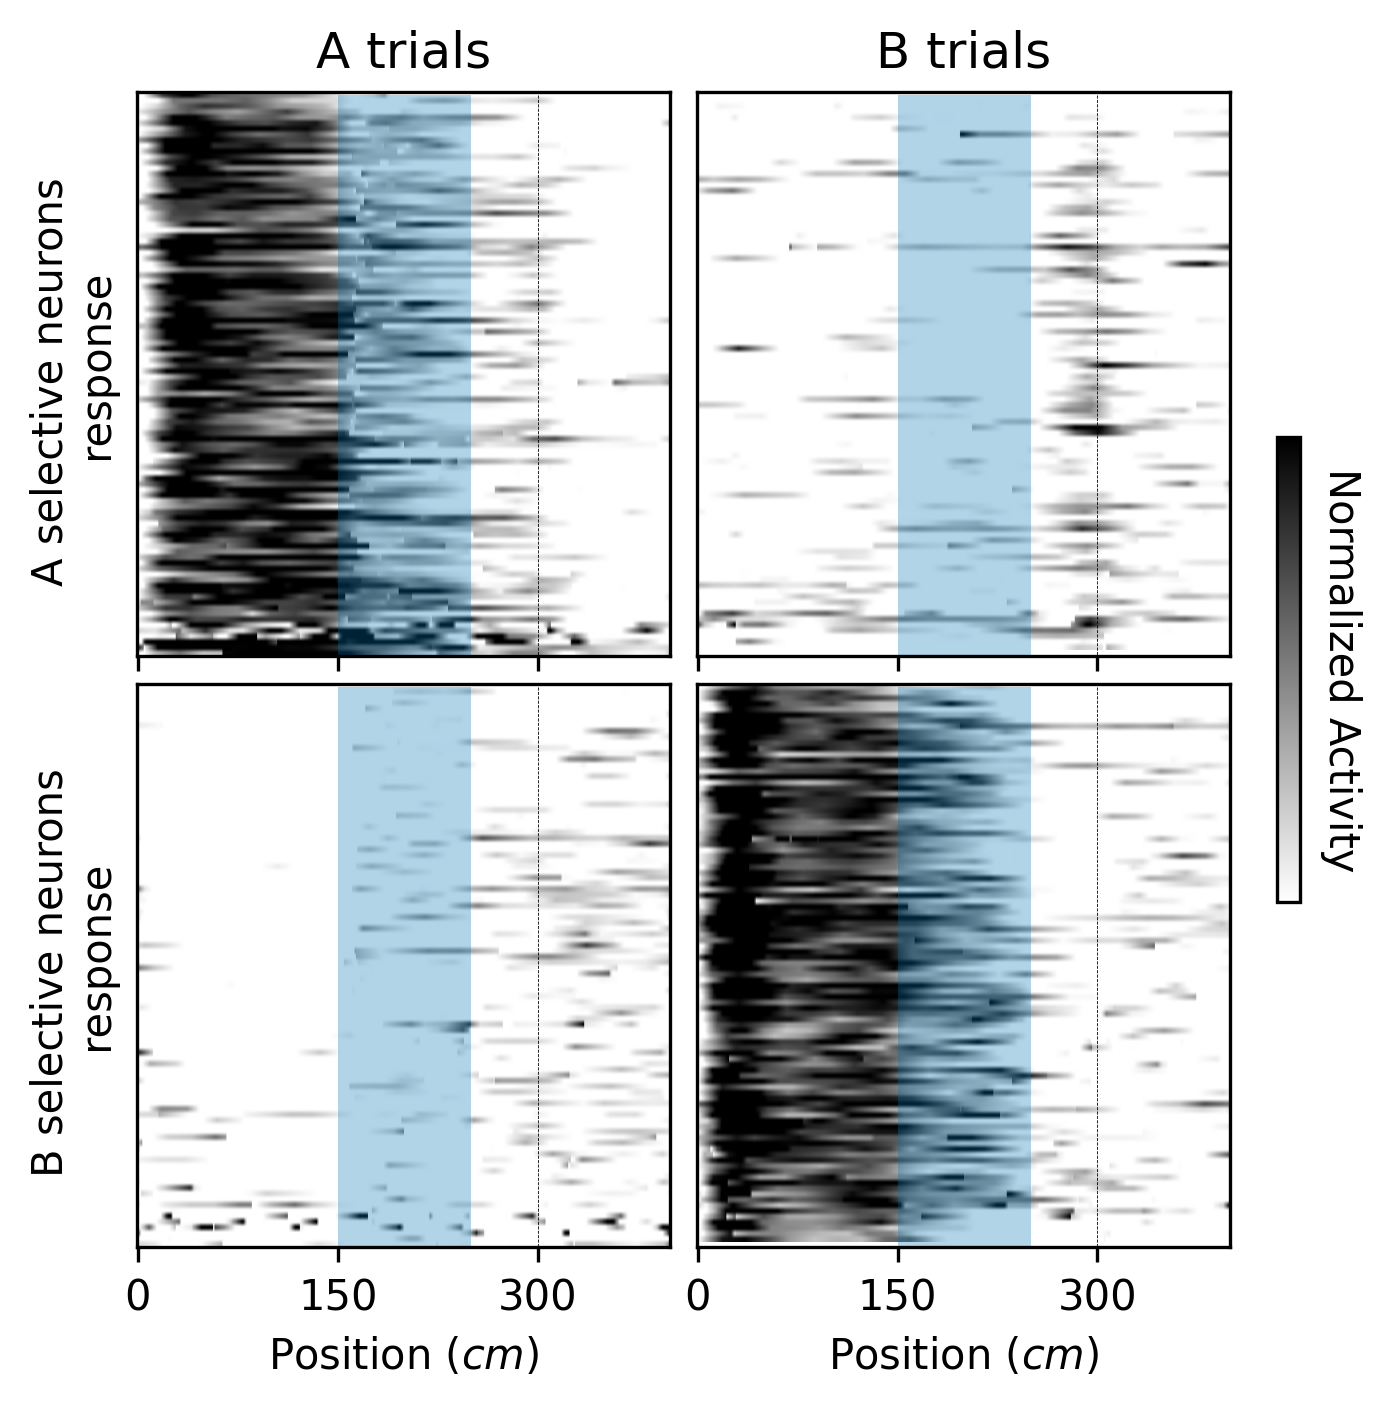

In [308]:
fig, ax = plt.subplots(2,2, figsize=(5,5), dpi=300, sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
selection = Anonprot_selective * ia * sel_type
resp = m.interp_spks[selection, :, :].mean(0)
ax[0,0].imshow(resp[A_trials], aspect='auto', cmap='grey_r', vmin=0, vmax=np.quantile(resp[A_trials], 0.90))
ax[0,1].imshow(resp[B_trials], aspect='auto', cmap='grey_r', vmin=0, vmax=np.quantile(resp[A_trials], 0.90))
selection = Bnonprot_selective * ia * sel_type
resp = m.interp_spks[selection, :, :].mean(0)
ax[1,0].imshow(resp[A_trials], aspect='auto', cmap='grey_r', vmin=0, vmax=np.quantile(resp[B_trials], 0.90))
ax[1,1].imshow(resp[B_trials], aspect='auto', cmap='grey_r', vmin=0, vmax=np.quantile(resp[B_trials], 0.90))
ax[0,0].set_title("A trials")
ax[0,1].set_title("B trials")
ax[0,0].set_ylabel("A selective neurons \n response")
ax[1,0].set_ylabel("B selective neurons \n response")
ax[1,0].set_xlabel("Position $(cm)$")
ax[1,1].set_xlabel("Position $(cm)$")
ax[0,0].set_yticks([])
ax[0,0].set_xticks([0,150, 300, 400])
#add colorbar
cbar = fig.colorbar(ax[0,1].images[0], ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
for axs in ax.flatten():
    axs.fill_betweenx([0, 99.5], [150],[250], color='#0072B2', edgecolor = "none", alpha=0.3)
    axs.vlines(300,0, 99.5, color='k', linestyle='--', linewidth=.2)
# remove colorbar ticks
cbar.set_ticks([])
cbar.set_label('Normalized Activity', rotation=270, labelpad=15)

In [298]:
ymax

np.float64(-0.5)

In [125]:
prp_df.to_csv(r"D:\mouseobj\proportion_cells_summary_1tsh.csv", index=False)

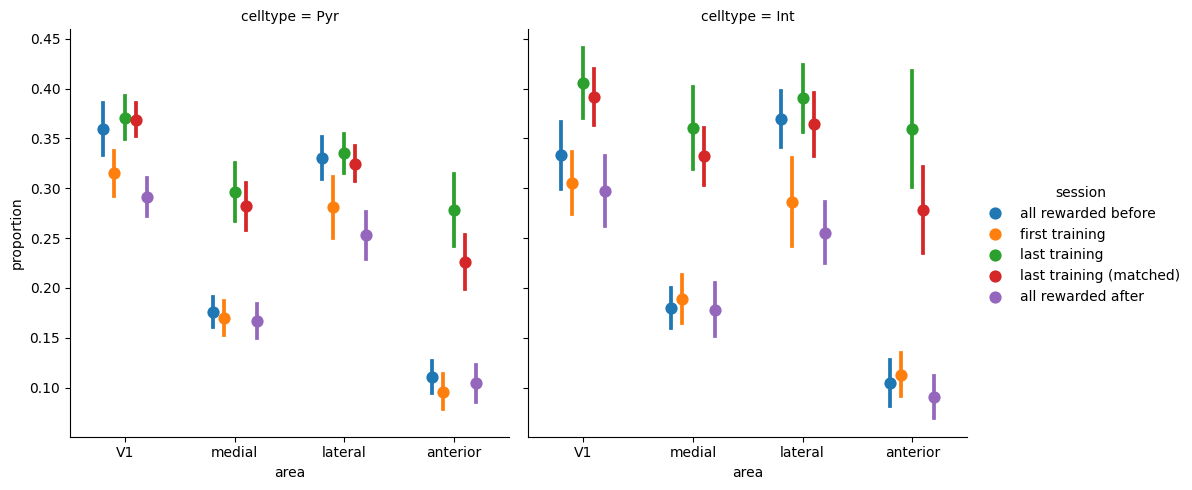

In [126]:
g = sns.catplot(data=prp_df.query("type == 'prototype'"), x="area", y="proportion", hue="session", col="celltype", order=areas, kind="point", errorbar="se", dodge=.4, linestyle = 'none')

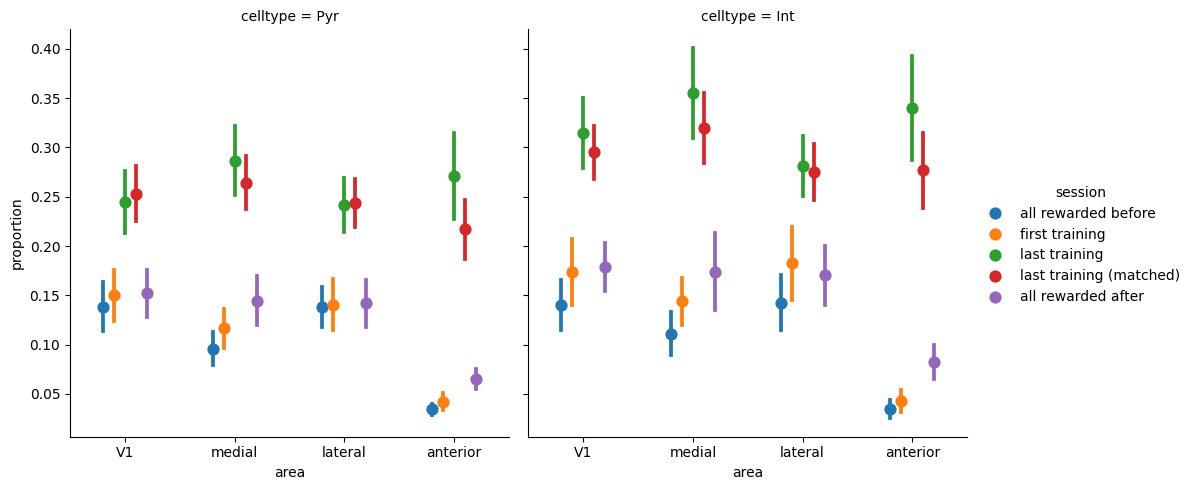

In [127]:
g = sns.catplot(data=prp_df.query("type == 'non prototype'"), x="area", y="proportion", hue="session", col="celltype", order=areas, kind="point", errorbar="se", dodge=.4, linestyle = 'none')

In [128]:
img.shape

(500, 500)

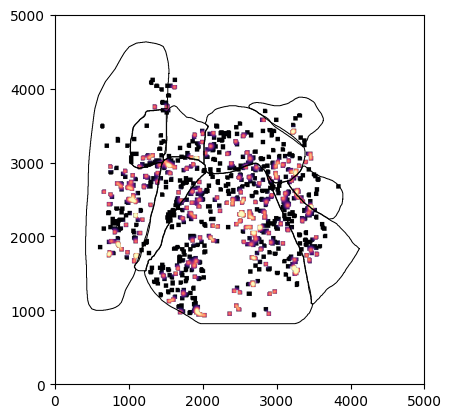

In [130]:
sz = img.shape[0]
scal = 10
plt.imshow(np.flipud(img), cmap='magma', vmax=vmax, extent=[0, sz*scal, 0, sz*scal], rasterized=True)
outlines = m.outline
temp_outline=[]
for j in range(10):
    if j!=7:
        temp = outlines[j].copy()
        temp[:,1] = -(-temp[:,1]+800-2500)+2500
        temp[:,0] = temp[:,0]+800
        plt.plot(temp[:,1],temp[:,0], linewidth=0.7, color='k')  
        temp_outline.append(temp)
    else:
        temp_outline.append([])

In [132]:
celltypes

['Pyr', 'Int']

In [133]:
nmice = 10
session_names = [ "first training", "last training (matched)"]
maps_vects = np.full((nmice, len(session_names), len(celltypes), 500, 500), np.nan)
for iss, sess in enumerate(session_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        for ic, cell in enumerate(celltypes):
            maps_vects[i, iss, ic, :, :] = np.load(save_pth.joinpath(f"spatial_density_map_{cell}.npy"))

Processing: first training
Processing: last training (matched)


In [134]:
overall_maps = np.nanmean(maps_vects, axis=0)  # average across mice

C:\Users\labadmin\AppData\Local\Temp\ipykernel_41316\670518746.py:1: RuntimeWarning: Mean of empty slice
  overall_maps = np.nanmean(maps_vects, axis=0)  # average across mice


Text(0, 0.5, 'Prop. of selective \n inhibitory neurons')

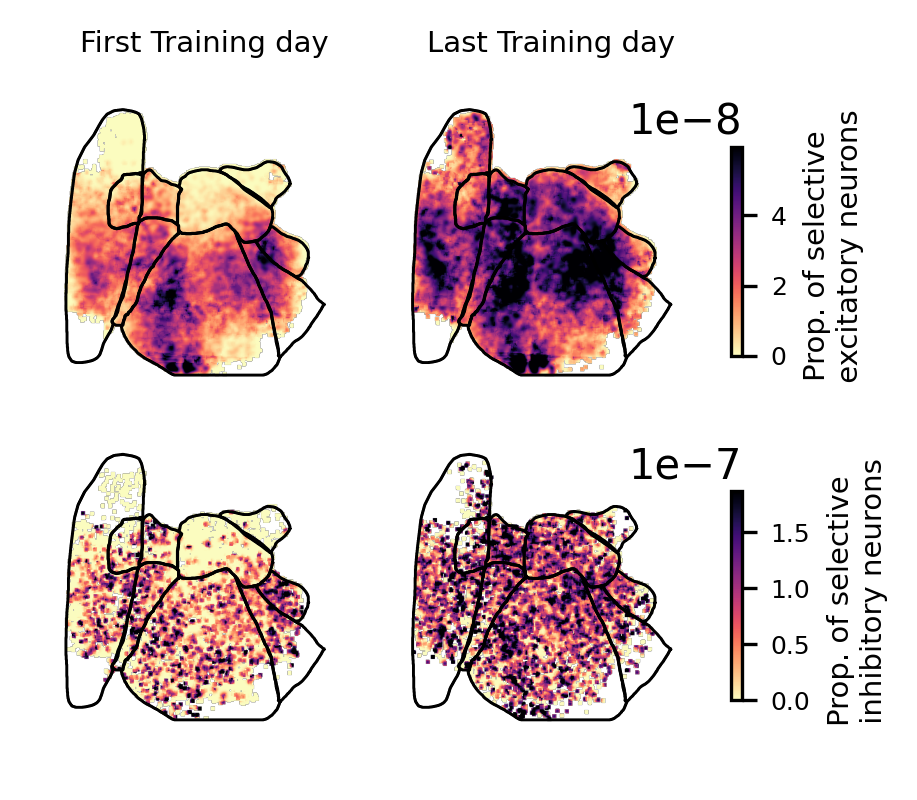

In [254]:
fig, ax = plt.subplots(2,2, figsize=(4,3), dpi=300)
fig.subplots_adjust(wspace=-0.5, hspace=-0.01)
ov_exc_test = overall_maps[1, 0, :, :]
vmax_exc = np.quantile(ov_exc_test[np.where(~np.isnan(ov_exc_test))], .90)
ov_inh_test = overall_maps[1, 1, :, :]
vmax_inh = np.quantile(ov_inh_test[np.where(~np.isnan(ov_inh_test))], .90)
for i in range(2):
    for j in range(2):
        img = overall_maps[i, j, :, :]
        vmax_plot = vmax_exc if j==0 else vmax_inh
        plot_density_map(ax[j, i], m, img, vmax = vmax_plot, cmap = "magma_r")
        ax[j, i].axis('off')
ax[0,0].set_title("First Training day", fontsize=7)
ax[0,1].set_title("Last Training day", fontsize=7)
cb1 = fig.colorbar(ax[0,1].images[0], ax=ax[0,1], shrink=0.6, pad=0.01)
cb1.ax.tick_params(labelsize=6)
cb1.ax.set_ylabel('Prop. of selective \n excitatory neurons', fontsize=7)
cb2 = fig.colorbar(ax[1,1].images[0], ax=ax[1,1], shrink=0.6, pad=0.01)
cb2.ax.tick_params(labelsize=6)
cb2.ax.set_ylabel('Prop. of selective \n inhibitory neurons', fontsize=7)

In [205]:
from src import fig1

In [207]:
prp_df

,name,datexp,blk,session,area,celltype,type,proportion
0,VG11,2024_10_15,4,all rewarded before,V1,Pyr,prototype,0.294950
1,VG11,2024_10_15,4,all rewarded before,V1,Pyr,non prototype,0.072466
2,VG11,2024_10_15,4,all rewarded before,V1,Int,prototype,0.287634
3,VG11,2024_10_15,4,all rewarded before,V1,Int,non prototype,0.048387
4,VG11,2024_10_15,4,all rewarded before,medial,Pyr,prototype,0.180310
...,...,...,...,...,...,...,...,...
779,VGa9,2025_11_21,2,all rewarded after,lateral,Int,non prototype,0.170732
780,VGa9,2025_11_21,2,all rewarded after,anterior,Pyr,prototype,0.184557
781,VGa9,2025_11_21,2,all rewarded after,anterior,Pyr,non prototype,0.090720
782,VGa9,2025_11_21,2,all rewarded after,anterior,Int,prototype,0.155405


In [211]:
prp_df

,name,datexp,blk,session,area,celltype,type,proportion
0,VG11,2024_10_15,4,all rewarded before,V1,Pyr,prototype,0.294950
1,VG11,2024_10_15,4,all rewarded before,V1,Pyr,non prototype,0.072466
2,VG11,2024_10_15,4,all rewarded before,V1,Int,prototype,0.287634
3,VG11,2024_10_15,4,all rewarded before,V1,Int,non prototype,0.048387
4,VG11,2024_10_15,4,all rewarded before,medial,Pyr,prototype,0.180310
...,...,...,...,...,...,...,...,...
779,VGa9,2025_11_21,2,all rewarded after,lateral,Int,non prototype,0.170732
780,VGa9,2025_11_21,2,all rewarded after,anterior,Pyr,prototype,0.184557
781,VGa9,2025_11_21,2,all rewarded after,anterior,Pyr,non prototype,0.090720
782,VGa9,2025_11_21,2,all rewarded after,anterior,Int,prototype,0.155405


In [209]:
def get_feature_values(df: pd.DataFrame, area: str, celltype: str, types: str, session: str, feature: str) -> np.ndarray:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}' & type == '{types}'")
    feature_values= b[feature].values
    return feature_values

In [214]:
p = get_feature_values(prp_df, "V1", "Pyr",  "prototype", "first training", "proportion")

In [216]:
p.shape

(10,)

In [218]:


sessions = ['first training', 'last training (matched)', 'last training']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
proportions = {}
for sess in sessions: 
    prps = np.empty((nmice, len(areas), len(celltype), 2))
    for itp, tpe in enumerate(['prototype', 'non prototype']):
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                p = get_feature_values(prp_df, area, ctype, tpe, sess, 'proportion')
                #store values
                prps[:,ia,ic, itp] = p
    proportions[sess] = prps


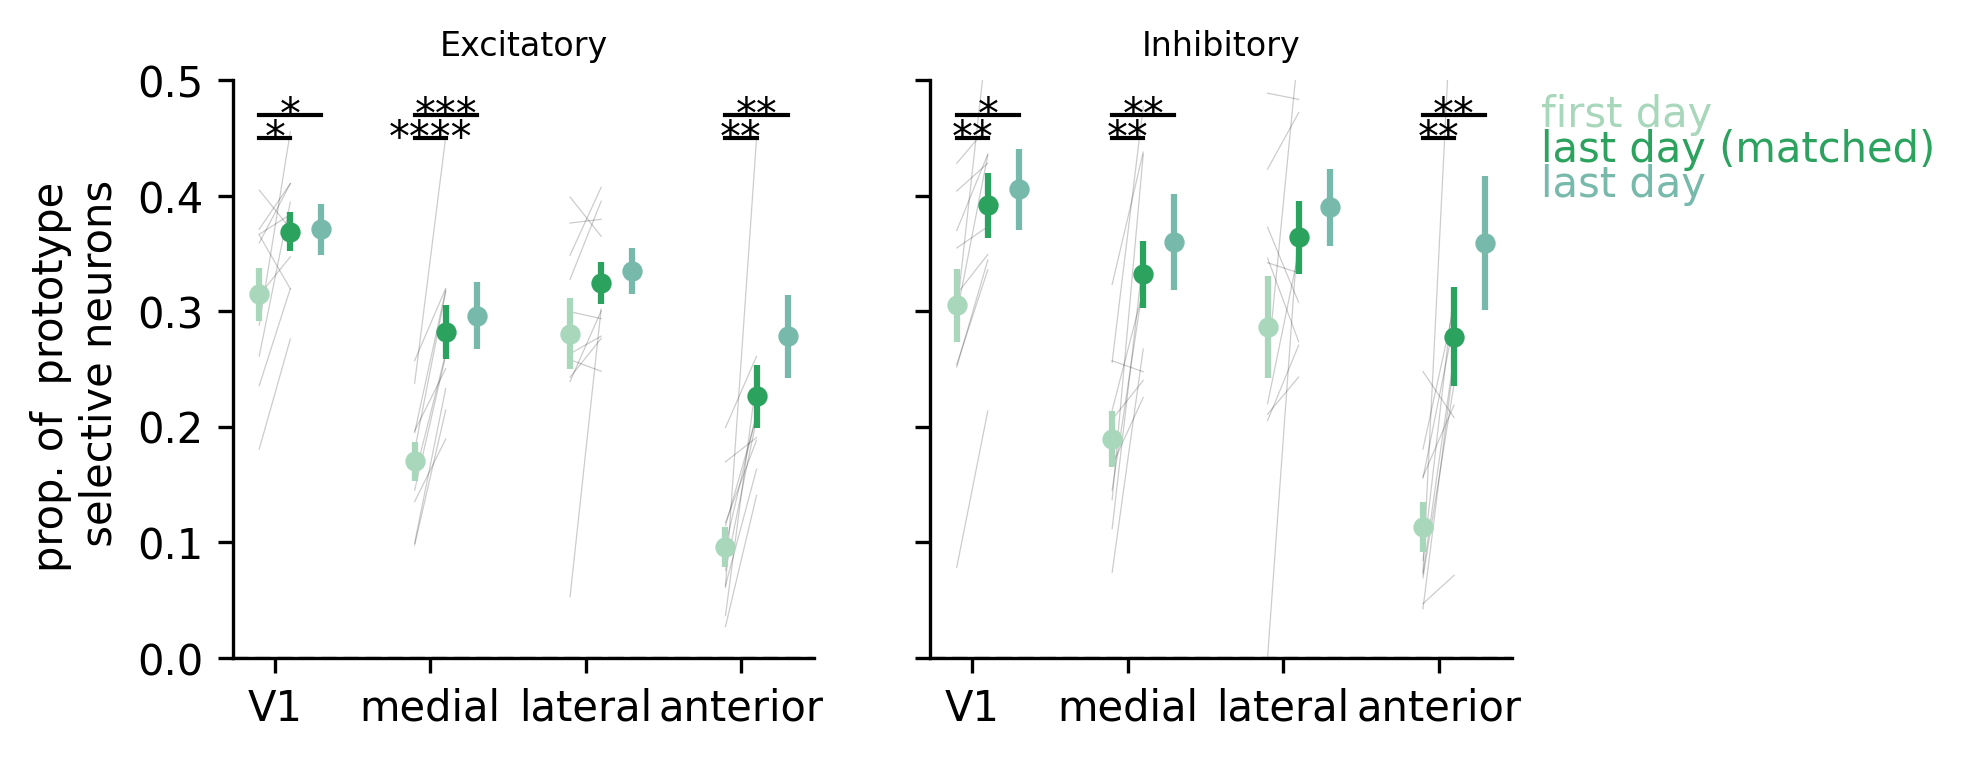

In [230]:
gis_first = proportions['first training'][:,:,:,0]
gis_last = proportions['last training'][:,:,:,0]
gis_last_m = proportions['last training (matched)'][:,:,:,0]
fig, ax = plt.subplots(1,2, figsize=(5.5,2.5), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.45, sig_line_control=.47, ylabel='prop. of  prototype \n selective neurons',
                                alternative=('two-sided', 'two-sided'), labels=['first day','last day (matched)', 'last day'])
ax[0].set_title('Excitatory', fontsize=8)
ax[1].set_title('Inhibitory', fontsize=8)
for a in ax.flatten():
    a.set_ylim(0,.5)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()

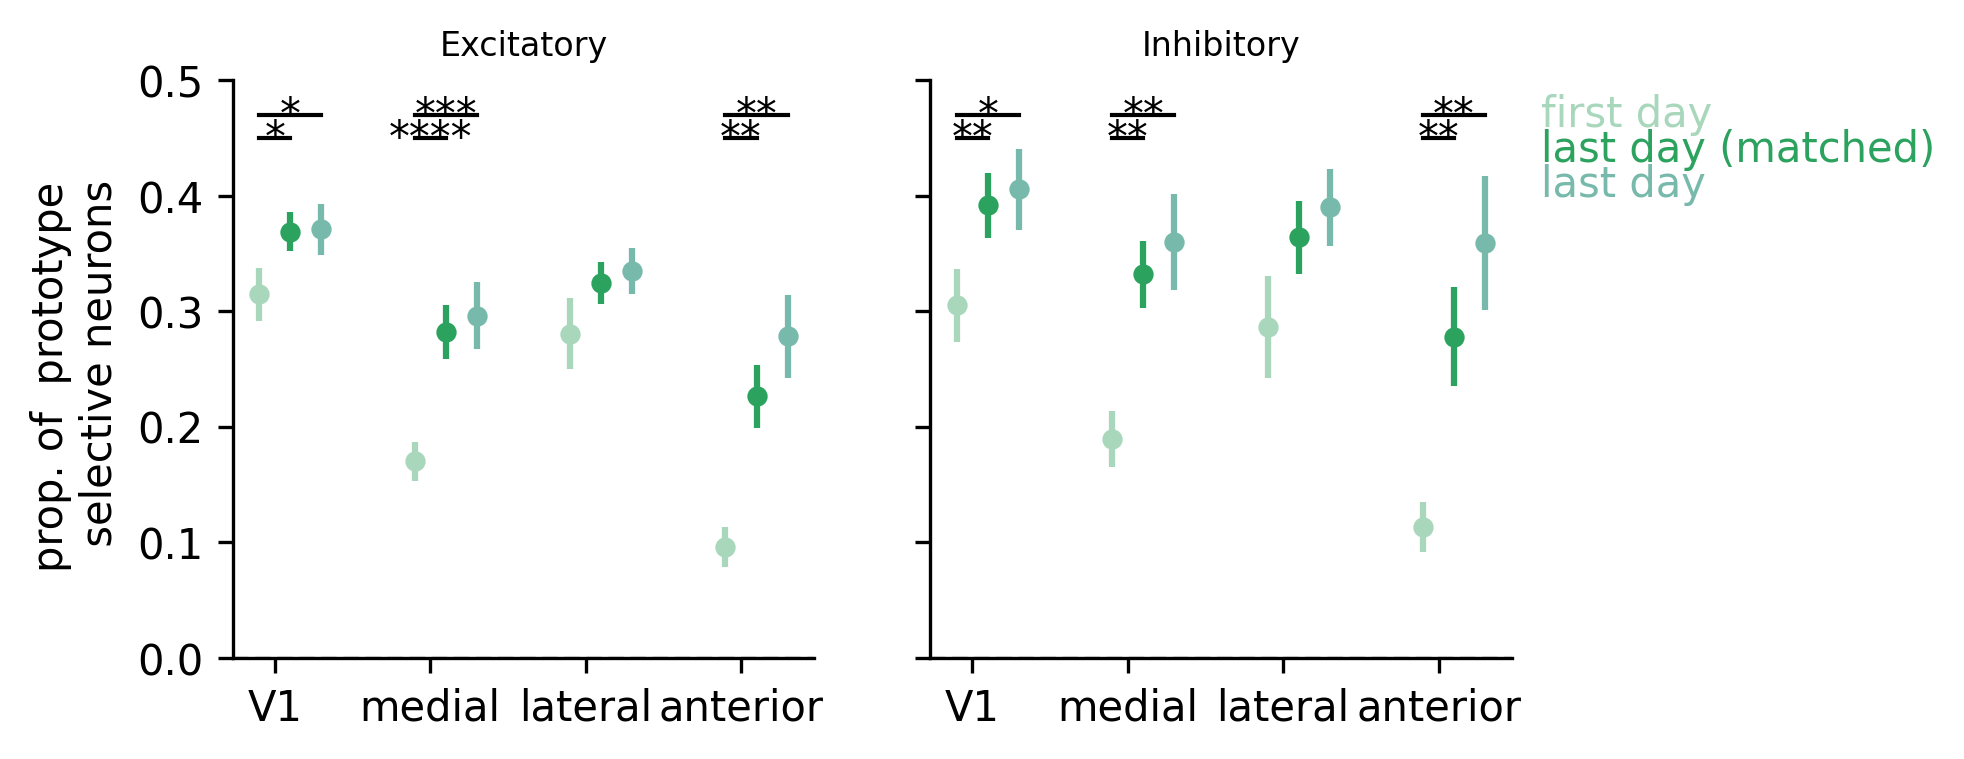

In [311]:
gis_first = proportions['first training'][:,:,:,0]
gis_last = proportions['last training'][:,:,:,0]
gis_last_m = proportions['last training (matched)'][:,:,:,0]
fig, ax = plt.subplots(1,2, figsize=(5.5,2.5), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.45, sig_line_control=.47, ylabel='prop. of  prototype \n selective neurons',
                                alternative=('two-sided', 'two-sided'), labels=['first day','last day (matched)', 'last day'], lines=False)
ax[0].set_title('Excitatory', fontsize=8)
ax[1].set_title('Inhibitory', fontsize=8)
for a in ax.flatten():
    a.set_ylim(0,.5)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()
plt.savefig(r"C:\Users\labadmin\Pictures\proportion_prototype_selective_comparison.svg", dpi=300)

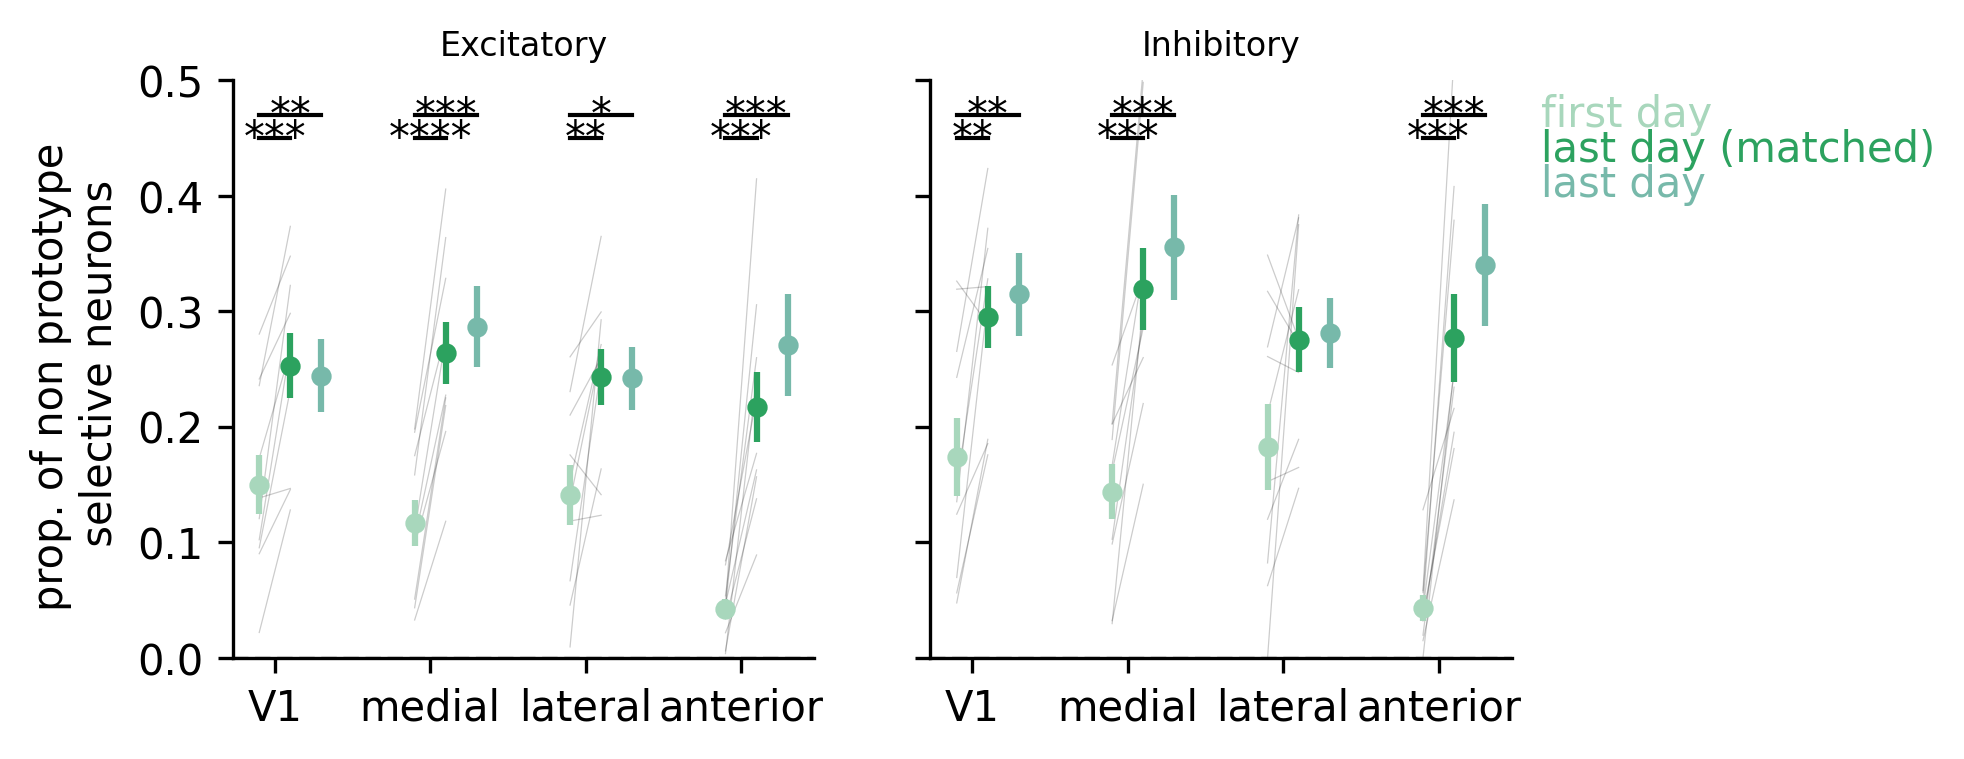

In [232]:
gis_first = proportions['first training'][:,:,:,1]
gis_last = proportions['last training'][:,:,:,1]
gis_last_m = proportions['last training (matched)'][:,:,:,1]
fig, ax = plt.subplots(1,2, figsize=(5.5,2.5), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.45, sig_line_control=.47, ylabel='prop. of non prototype \n selective neurons',
                                alternative=('two-sided', 'two-sided'), labels=['first day','last day (matched)', 'last day'])
ax[0].set_title('Excitatory', fontsize=8)
ax[1].set_title('Inhibitory', fontsize=8)
for a in ax.flatten():
    a.set_ylim(0,.5)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()

In [241]:
def compute_cell_change(m, session, tsh=.5, position = (0,100)):
    areas = ["V1", "medial", "lateral", "anterior"]
    ctypes = 2
    obj_path = Path(r"D:\mouseobj")
    proportion = np.empty((len(areas), ctypes, 2)) #areas, cell types, prototype/non-prototype
    if session == "last training (matched)":
        trial_dict = get_matched_trials(m)
    else:
        trial_dict = m.trial_dict
    dp_prot = dprime_cell(m.interp_spks, trial_dict["rewarded"], trial_dict["non rewarded"], discrimination_region=position, subpop=None)
    dp_nonprot = dprime_cell(m.interp_spks, trial_dict["rewarded test"], trial_dict["non rewarded test"], discrimination_region=position, subpop=None)
    for indexa, area in enumerate(areas):
        ia = utils.get_region_idx(m.iarea, area)
        for celltype in range(ctypes):
            sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if celltype == 0 else m.isred[:, 0].astype(bool)   
            prot_selective = np.abs(dp_prot) >= tsh
            nonprot_selective = np.abs(dp_nonprot) >= tsh
            area_type_prot_sel = prot_selective * ia * sel_type
            area_type_nonprot_sel = nonprot_selective * ia * sel_type
            total_in_area_type = (ia * sel_type).sum()
            proportion[indexa, celltype, 0] = (area_type_prot_sel.sum()) / total_in_area_type
            proportion[indexa, celltype, 1] = (area_type_nonprot_sel.sum()) / total_in_area_type
    return proportion

In [251]:
rows = []
obj_path = Path(r"D:\mouseobj")
areas = ['V1', 'medial', 'lateral', 'anterior']
celltypes = ['Pyr', 'Int']
sessions_names = ["first training", "last training (matched)"]
pos_bins = [(0,25), (0,50), (0,75), (0,100), (0,125), (0,150)]
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        for ibin, bin_ in enumerate(pos_bins):
            prop = compute_cell_change(m, sess, tsh=.5, position=bin_)
            for area_idx, area in enumerate(areas):
                for cell_idx, cell in enumerate(celltypes):
                    rows.append({"name": name, "datexp": datexp, "blk": blk, "session": sess, "area": area, "celltype": cell,
                                 "type": "prototype", "bin": ibin, "proportion": prop[area_idx, cell_idx, 0]})
                    rows.append({"name": name, "datexp": datexp, "blk": blk, "session": sess, "area": area, "celltype": cell,
                             "type": "non prototype", "bin": ibin, "proportion": prop[area_idx, cell_idx, 1]})
    clear_output(wait=True)
prp_df_pos = pd.DataFrame(rows)
prp_df_pos.to_csv(r"D:\mouseobj\overall\proportion_cells_summary_1tsh_positions.csv", index=False)

Processing: last training (matched)
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG

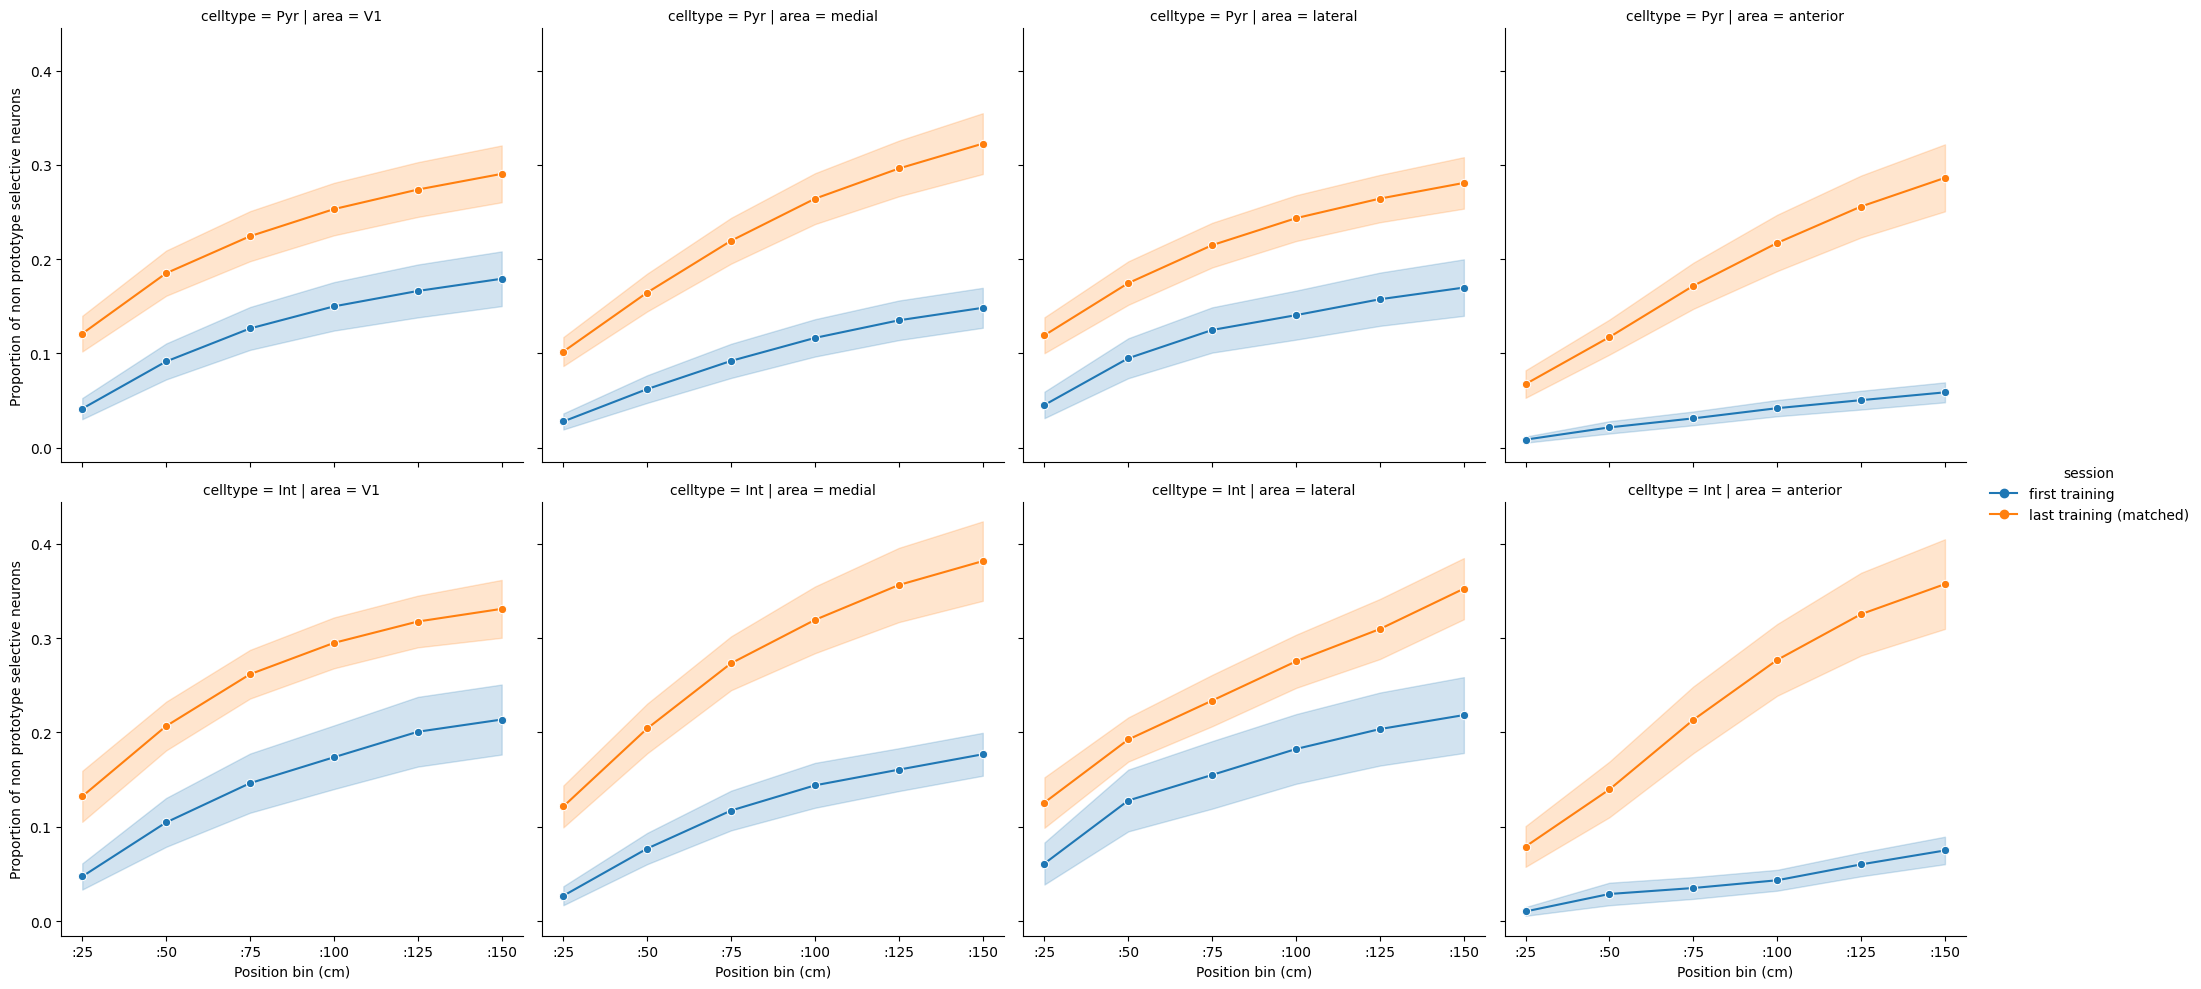

In [261]:
g = sns.relplot(data=prp_df_pos.query("type == 'non prototype'"), x="bin", y="proportion", hue="session", col="area", row="celltype", kind="line", errorbar="se", marker="o")
g.set_axis_labels("Position bin (cm)", "Proportion of non prototype selective neurons")
bins = sorted(prp_df_pos["bin"].unique())
labels = [":25", ":50", ":75", ":100", ":125", ":150"][:len(bins)]
for ax in g.axes.flat:
    ax.set_xticks(bins)
    ax.set_xticklabels(labels)